## RL Book Graphics 5
- Trimmed down from `rl_book_graphics_2.ipynb`: just what's needed for the rollout gradient-direction figures.
- Same 4 rollouts in every figure: direction only, scaled by return $R(\tau)$, scaled by GRPO advantage.

In [10]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path as FilePath

CHILL_BROWN="#948979"
ORANGE='#eb8423'
LT_BLUE='#5badb6'
GREEN='#419c52'
PINK='#ed5e78'

DATA = FilePath("/Users/stephen/ai_book_vol_2/chapters/08-reinforcement-learning/data")
# SAVE_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/ai_book_vol_2/8_reinforcement_learning/graphics/'

HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
SAVE_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/8_reinforcement_learning/graphics'

In [11]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [12]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

def style_cbar(cbar, color=CHILL_BROWN):
    cbar.outline.set_edgecolor(color)
    cbar.ax.tick_params(colors=color, which='both')
    cbar.ax.yaxis.label.set_color(color)
    cbar.ax.xaxis.label.set_color(color)
    cbar.ax.title.set_color(color)

### Policy + stochastic rollouts

In [13]:
VEL_SCALE = 10   # divide velocities by 10 -> feature scales comparable, ~isotropic parameter space

class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity."""
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        logit = x @ self.theta.to(x.dtype)         # compute at the precision of the input
        return torch.sigmoid(logit)

def to_features(state):
    """Gymnasium state [x, x_dot, angle, ang_vel] (radians) -> the 2 features our agent uses."""
    f = torch.tensor(state[2:4], dtype=torch.float32) * 180/np.pi   # angle, angular velocity in degrees
    f[1] = f[1] / VEL_SCALE
    return f

def run_episode_stochastic(agent, env_seed, policy_seed, max_steps=500):
    """The agent pushes right with probability yhat."""
    env = gym.make("CartPole-v1")
    state, _ = env.reset(seed=env_seed)
    rng = np.random.default_rng(policy_seed)             # policy randomness, independent of the starting state
    X_ep, y_ep = [], []
    for t in range(max_steps):
        with torch.no_grad():
            features = to_features(state)
            action = int(rng.random() < agent(features))   # push right with probability yhat
        X_ep.append(features); y_ep.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated: break
    return torch.stack(X_ep), torch.tensor(y_ep)

In [14]:
f=np.load(DATA / 'return_landscape_stochastic_256x256_1024_-1.0+1.0.npz')
R_mean_sto=f['R_mean']
theta1_vals_R=f['theta1_vals']; theta2_vals_R=f['theta1_vals']

### The 4 rollouts
Each rollout only depends on its own `policy_seed`, so we can regenerate just these 4 and get exactly the same episodes as rollouts 0, 15, 234 and 576 of the original 1000.

In [15]:
samples = [0, 15, 234, 576]
colors = [GREEN, ORANGE, PINK, LT_BLUE]

theta_0 = torch.tensor([-0.5, 0.0])
agent = Pi()
with torch.no_grad(): agent.theta[:] = theta_0

rollouts = {k: run_episode_stochastic(agent, env_seed=0, policy_seed=k) for k in samples}   # same start every time
lengths  = {k: len(y_ep) for k, (_, y_ep) in rollouts.items()}                               # R(tau) = episode length

In [16]:
probs, grad_probs = {}, {}
for k, (X_ep, y_ep) in rollouts.items():
    with torch.no_grad():
        x = X_ep.double()                                       # float64: P underflows float32 on long rollouts
        yhat = agent(x)
        p_t  = torch.where(y_ep == 1, yhat, 1 - yhat)           # probability of each action actually taken
        sign = torch.where(y_ep == 1, 1.0, -1.0)                # d p_t / d yhat: +1 for right, -1 for left
        dp_dtheta = (sign * yhat * (1 - yhat))[:, None] * x     # (T, 2): d p_t / d theta, via the sigmoid derivative

        P = p_t.prod()
        probs[k] = P.item()
        grad_probs[k] = ((P / p_t)[:, None] * dp_dtheta).sum(0).numpy()   # product rule: sum_t (product of all other p's) * dp_t/dtheta

for k in samples:
    print(f'rollout {k:4d}: {lengths[k]:3d} steps,  P = {probs[k]:.2e}', grad_probs[k])

rollout    0:   8 steps,  P = 3.91e-01 [-1.15728689 -1.17911148]
rollout   15:  10 steps,  P = 7.81e-02 [-0.08722175 -0.07075484]
rollout  234:  10 steps,  P = 6.14e-02 [-0.09042747 -0.17266709]
rollout  576:  23 steps,  P = 1.50e-07 [1.25973585e-06 1.08017170e-06]


In [23]:
def plot_rollout_arrows(arrow_lens, fname, avg_len=0.3):
    """Return landscape with one arrow per sampled rollout, starting at theta_0.
    Each arrow points along grad p_theta(tau) (normalized) and has signed length arrow_lens[k]
    in theta units -- a negative length flips the arrow.
    The white arrow is the average of the colored arrows: drawn direction-only at length avg_len,
    or at its true length (the mean of the 4 vectors) if avg_len=None."""
    th0 = theta_0.numpy()
    fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111)
    extent = [theta1_vals_R[0], theta1_vals_R[-1], theta2_vals_R[0], theta2_vals_R[-1]]
    im = ax.imshow(R_mean_sto.T, origin='lower', cmap='viridis', extent=extent, aspect='equal')
    ax.set_xlabel(r'$\theta_1$ (pole angle parameter)'); ax.set_ylabel(r'$\theta_2$ (pole angular velocity parameter)')
    cbar = plt.colorbar(im, label='Average episode length (Return)', shrink=0.8)

    order = sorted(zip(samples, colors), key=lambda kc: -abs(arrow_lens[kc[0]]))   # longest first, so short arrows sit on top
    us = {k: arrow_lens[k] * grad_probs[k] / np.linalg.norm(grad_probs[k]) for k in samples}
    for k, c in order:
        ax.annotate('', xy=th0 + us[k], xytext=th0, arrowprops=dict(arrowstyle='-|>', color=c, lw=2.4, mutation_scale=18))

    avg = np.mean([us[k] for k in samples], axis=0)                 # average of the 4 arrows as drawn
    u_avg = avg if avg_len is None else avg_len * avg / np.linalg.norm(avg)
    ax.annotate('', xy=th0 + u_avg, xytext=th0, zorder=6, arrowprops=dict(arrowstyle='-|>', color='w', lw=3.2, mutation_scale=24)) #, alpha=0.85))
    print(f'average arrow: [{avg[0]:+.3f}, {avg[1]:+.3f}]  length {np.linalg.norm(avg):.3f}  '
          f'direction {np.degrees(np.arctan2(avg[1], avg[0])):+.1f} deg')
    ax.scatter(*th0, c='w', s=40, zorder=7)
    ax.set_xticks([-1, -0.5, 0, .5, 1])
    ax.set_yticks([-1, -0.5, 0, .5, 1])
    style_ax(ax); style_cbar(cbar)
    plt.savefig(SAVE_DIR + fname)
    return fig, ax

### 1. Direction only (original cell 96)
Which direction makes each rollout more likely?

average arrow: [-0.118, -0.158]  length 0.197  direction -126.8 deg


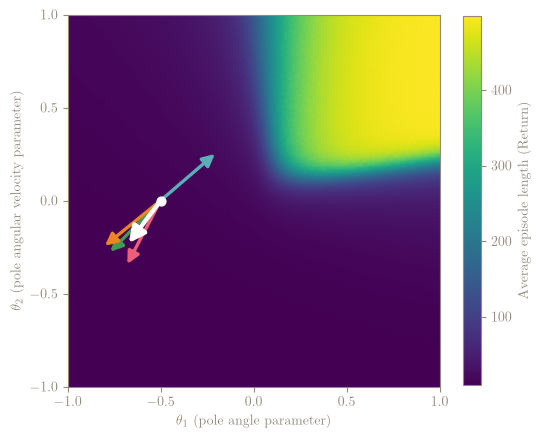

In [25]:
arrow_len = 0.4
plot_rollout_arrows({k: arrow_len for k in samples}, '/rollout_compare_1.svg');

### 2. Scaled by return
Same normalized directions, arrow length $\propto R(\tau)$. The longest rollout gets length `MAX_ARROW_LEN`.

rollout    0:  R =   8   arrow length = 0.209
rollout   15:  R =  10   arrow length = 0.261
rollout  234:  R =  10   arrow length = 0.261
rollout  576:  R =  23   arrow length = 0.600
average arrow: [-0.004, -0.038]  length 0.039  direction -95.3 deg


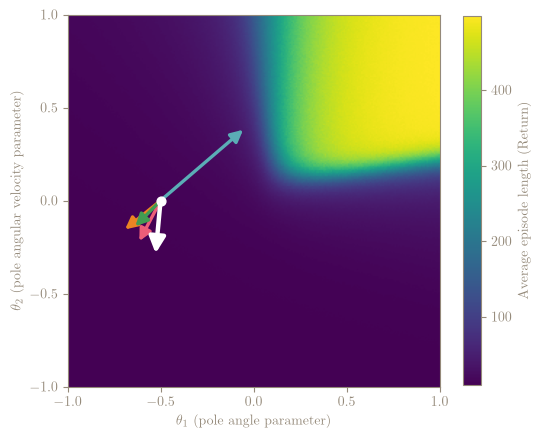

In [27]:
MAX_ARROW_LEN = 0.6   # length of the longest arrow, in theta units

R = np.array([lengths[k] for k in samples], dtype=float)
return_lens = dict(zip(samples, MAX_ARROW_LEN * R / R.max()))

for k in samples:
    print(f'rollout {k:4d}:  R = {lengths[k]:3d}   arrow length = {return_lens[k]:.3f}')
plot_rollout_arrows(return_lens, '/rollout_compare_return_scaled_1.svg');

### 3. Scaled by GRPO advantage
$$
A_i = \frac{R_i - \text{mean}(R)}{\text{std}(R)}
$$
with the mean and standard deviation taken over our group of 4 rollouts. Below-average rollouts get a negative advantage, which flips their arrows: move $\theta$ to make them *less* likely. The largest $|A_i|$ gets length `MAX_ARROW_LEN`.

In [30]:
MAX_ARROW_LEN

0.6

In [31]:
MAX_ARROW_LEN=0.8

rollout    0:  R =   8   A = -0.795   arrow length = -0.371
rollout   15:  R =  10   A = -0.460   arrow length = -0.215
rollout  234:  R =  10   A = -0.460   arrow length = -0.215
rollout  576:  R =  23   A = +1.716   arrow length = +0.800
average arrow: [+0.283, +0.278]  length 0.397  direction +44.4 deg


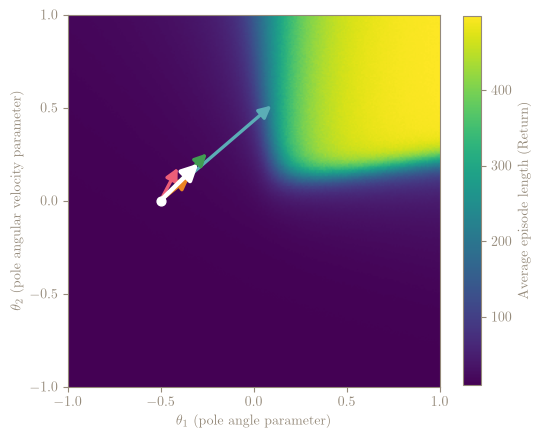

In [32]:
adv = (R - R.mean()) / R.std()                        # GRPO: normalize returns within the group
grpo_lens = dict(zip(samples, MAX_ARROW_LEN * adv / np.abs(adv).max()))

for k, a in zip(samples, adv):
    print(f'rollout {k:4d}:  R = {lengths[k]:3d}   A = {a:+.3f}   arrow length = {grpo_lens[k]:+.3f}')
plot_rollout_arrows(grpo_lens, '/rollout_compare_grpo_1.svg');

In [29]:
grpo_lens

{0: np.float64(-0.2780487804878049),
 15: np.float64(-0.16097560975609754),
 234: np.float64(-0.16097560975609754),
 576: np.float64(0.6)}

In [33]:
R

array([ 8., 10., 10., 23.])

In [34]:
adv

array([-0.79512525, -0.46033567, -0.46033567,  1.7157966 ])

In [35]:
R.mean()

np.float64(12.75)

In [36]:
R.std()

np.float64(5.973901572674261)